Setup and imports

In [21]:
import cobra
import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [22]:
model = cobra.io.load_json_model("e_coli_core-1.json")

1а) No, as the maximal reaction activities (unlike fluxes) can be unequal along the linear pathway
In 2 consequent reactions flux of the first reaction would be a bottleneck, therefore the second can have the same flux as the first reaction
Maximal reaction activity determines the maximum of activity that potentially a reaction can have, that is why 2 consequent reactions can have different maximums
For example, PFK (13.1) != FBA (30.4) != GAPD (24.5) are not equal along the pathway
1b) Two types of values that can be observed on reactions with grey arrows: "0.00"(for example, PFL, LDH_D) and "no data"(for example, FORti, H2Ot).
"0.00" - the maximal reaction activity was measured and it is equal to 0.00 (numerical value exists)
"no data" - the maximal reaction activity is not determined

In [23]:
Task 2

SyntaxError: invalid syntax (2919465053.py, line 1)

In [24]:
activity = {}

filename = "KEN3170_Assignment_2026_e_coli_core_expression.csv"

with open(filename, mode="r", newline="") as file:
    reader = csv.reader(file)
    header = next(reader)

    for row in reader:
        reaction_id = row[0].strip()
        value = float(row[1])
        activity[reaction_id] = value

print("Number of reactions with activity data:", len(activity))

Number of reactions with activity data: 65


In [25]:
list(activity.items())[:10]

[('PFK', 13.1),
 ('PFL', 0.0),
 ('PGI', 11.1),
 ('PGK', 24.0),
 ('PGL', 7.3),
 ('ACALD', 0.0),
 ('AKGt2r', 0.0),
 ('PGM', 21.7),
 ('PIt2r', 5.2),
 ('ALCD2x', 0.0)]

In [26]:
ATPM = model.reactions.get_by_id("ATPM")
original_ATPM_lower_bound = ATPM.lower_bound

print(original_ATPM_lower_bound)

8.39


In [27]:
for reaction in model.reactions:

    if reaction.id in activity:

        value = activity[reaction.id]

        if reaction.reversibility:
            reaction.lower_bound = -value
            reaction.upper_bound = value

        else:
            reaction.upper_bound = value

In [28]:
model.reactions.get_by_id("ATPM").lower_bound = original_ATPM_lower_bound

In [29]:
model.reactions.get_by_id("ATPM")

Reaction identifier,ATPM
Name,ATP maintenance requirement
Memory address,0x210507f0590
Stoichiometry,atp_c + h2o_c --> adp_c + h_c + pi_c ATP C10H12N5O13P3 + H2O H2O --> ADP C10H12N5O10P2 + H+ + Phosphate
GPR,
Lower bound,8.39
Upper bound,1000.0


In [30]:
glc = model.reactions.get_by_id("EX_glc__D_e")

glc.lower_bound = -1000
glc.upper_bound = 1000

In [31]:
glc

Reaction identifier,EX_glc__D_e
Name,D-Glucose exchange
Memory address,0x2104e409250
Stoichiometry,glc__D_e <=> D-Glucose <=>
GPR,
Lower bound,-1000
Upper bound,1000


In [32]:
final_printout_table = pd.DataFrame({
    "Reaction": [r.id for r in model.reactions],
    "Lower bound": [r.lower_bound for r in model.reactions],
    "Upper bound": [r.upper_bound for r in model.reactions]
})

final_printout_table

,Reaction,Lower bound,Upper bound
0,PFK,0.0,13.1
1,PFL,0.0,0.0
2,PGI,-11.1,11.1
3,PGK,-24.0,24.0
4,PGL,0.0,7.3
...,...,...,...
90,NADH16,0.0,40.1
91,NADTRHD,0.0,1.3
92,NH4t,-1000.0,1000.0
93,O2t,-1000.0,1000.0


3a) 

In [33]:
# Reset glucose to the bounds from point 2 so this section can be rerun.
glc = model.reactions.get_by_id("EX_glc__D_e")
glc.lower_bound = -1000
glc.upper_bound = 1000

model.objective = "BIOMASS_Ecoli_core_w_GAM"
model.objective_direction = "max"
solution_3a = model.optimize()

print("solver status ", solution_3a.status)
print("max biomass production rate", round(solution_3a.objective_value, 6), "h^-1")
print("glucose exchange flux", round(solution_3a.fluxes["EX_glc__D_e"], 6), "mmol/gDW/h")

solver status  optimal
max biomass production rate 0.873286 h^-1
glucose exchange flux -10.620457 mmol/gDW/h


The maximal biomass production rate is about **0.873286 h^-1**. Glucose uptake has a high default bound here, so growth is limited by the reaction capacities and the other model constraints.

3b)
This limit means the cell can take up at most 5 mmol/gDW/h of glucose from its surroundings. We use -5 because glucose uptake is negative in this model. The limits from the expression data describe how much the enzymes can do. This new limit describes how much glucose is available to the cell.

In [34]:
glc.lower_bound = -5

print("Glucose exchange bounds:", glc.bounds)

Glucose exchange bounds: (-5, 1000)


 3c) 

In [35]:
solution_3c = model.optimize()

print("solver status", solution_3c.status)
print("max biomass production rate", round(solution_3a.objective_value, 6), "h^-1")
print("glucose exchange flux", round(solution_3a.fluxes["EX_glc__D_e"], 6), "mmol/gDW/h")

percentage_decrease = 100 * (solution_3a.objective_value - solution_3c.objective_value) / solution_3a.objective_value
print("Decrease in biomass production:", round(percentage_decrease, 2), "%")

solver status optimal
max biomass production rate 0.873286 h^-1
glucose exchange flux -10.620457 mmol/gDW/h
Decrease in biomass production: 52.41 %


The growth rate drops from 0.873286 to 0.415598 , so it is about 52.4% lower. In 3a the cell takes up about 10.62 mmol/gDW/h of glucose. Now it can only take up 5 and uses all of that allowance.

With less glucose the cell has less carbon and energy for growth. It still needs ATP for basic maintenance. The enzyme limits stay the same but the lower glucose supply means the cell cannot grow as fast.

4a)

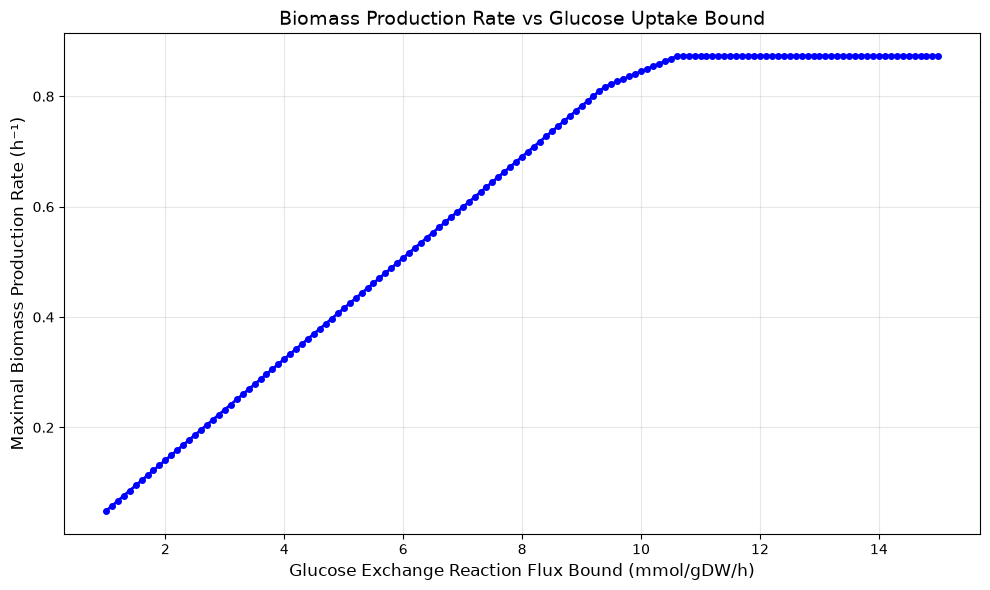

Glucose bounds: [np.float64(1.0), np.float64(1.1), np.float64(1.2000000000000002), np.float64(1.3000000000000003), np.float64(1.4000000000000004)] ...
biomass rates: [0.048385, 0.05768, 0.066974, 0.076269, 0.085563] ...


In [ ]:

glc = model.reactions.get_by_id("EX_glc__D_e")
glc.lower_bound = -1000
glc.upper_bound = 1000


glucose_bounds = np.arange(1, 15.1, 0.1)
biomass_rates = []


for glc_bound in glucose_bounds:
    glc.lower_bound = -glc_bound 
    glc.upper_bound = 1000
    
    solution = model.optimize()
    if solution.status == "optimal":
        biomass_rates.append(solution.objective_value)
    else:
        biomass_rates.append(None)

plt.figure(figsize=(10, 6))
plt.plot(glucose_bounds, biomass_rates, 'b-', linewidth=2, marker='o', markersize=4)
plt.xlabel('Glucose Exchange Reaction Flux Bound (mmol/gDW/h)', fontsize=12)
plt.ylabel('Maximal Biomass Production Rate (h⁻¹)', fontsize=12)
plt.title('Biomass Production Rate vs Glucose Uptake Bound', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Glucose bounds:", list(glucose_bounds[:5]), "...")
print("biomass rates:", [round(b, 6) for b in biomass_rates[:5]], "...")

4b)

In [ ]:

print("Summary statistics:")
print(f"Min biomass rate: {min([b for b in biomass_rates if b is not None]):.6f} at glucose bound 1.0")
print(f"Max biomass rate: {max([b for b in biomass_rates if b is not None]):.6f} at glucose bound {glucose_bounds[biomass_rates.index(max(biomass_rates))]:.1f}")
print(f"\nBiomass rates at different glucose bounds:")
for i in [0, 10, 50, 100, 140]:
    if i < len(glucose_bounds):
        print(f"Glucose = {glucose_bounds[i]:5.1f} mmol/gDW/h: Biomass = {biomass_rates[i]:.6f} h^-1")


differences = np.diff(biomass_rates)
print(f"\nLast 10 biomass rate differences: {[round(d, 8) for d in differences[-10:]]}")

Summary statistics:
Min biomass rate: 0.048385 at glucose bound 1.0
Max biomass rate: 0.873286 at glucose bound 10.8

Biomass rates at different glucose bounds:
Glucose =   1.0 mmol/gDW/h: Biomass = 0.048385 h^-1
Glucose =   2.0 mmol/gDW/h: Biomass = 0.140604 h^-1
Glucose =   6.0 mmol/gDW/h: Biomass = 0.507263 h^-1
Glucose =  11.0 mmol/gDW/h: Biomass = 0.873286 h^-1
Glucose =  15.0 mmol/gDW/h: Biomass = 0.873286 h^-1

Last 10 biomass rate differences: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


In [ ]:
## 4c)
test_points = [1.0, 3.5, 7.0, 11.0, 15.0] 

exchange_reactions = [r for r in model.reactions if r.id.startswith("EX_")]
print(f"Total exchange reactions: {len(exchange_reactions)}\n")

for glc_bound in test_points:
    glc.lower_bound = -glc_bound
    glc.upper_bound = 1000
    solution = model.optimize()
    
    print(f"--- Glucose bound: {glc_bound} mmol/gDW/h, Biomass: {solution.objective_value:.6f} h^-1 ---")
    

    active_exchanges = []
    for rxn in exchange_reactions:
        flux = solution.fluxes[rxn.id]
        if abs(flux) > 1e-6:  # Only shows significant fluxes
            active_exchanges.append((rxn.id, flux))
    
    # sorts by absolute flux value
    active_exchanges.sort(key=lambda x: abs(x[1]), reverse=True)
    
    print("Active exchange reactions (flux > 1e-6):")
    for rxn_id, flux in active_exchanges[:8]:  # Show top 8
        print(f"  {rxn_id:15s}: {flux:10.4f}")
    print()

4b)

the curve indicates that the growth rate does not increase indefinitely with glucose flux. 


In segment 1 (glucose ~1-3), there is a linear increase in biomass production rate. The growth is limited by glucose availability. In segment 2 which is glucode 3-7 there is a secondary constraint (such as oxygen or another nutrient) that becomes active which reduces growth rate. In the last segment where glucose levels are at approx 7 to 15, the curve completely plateaus

3. Segment 3 (glucose approx 7-15): The curve plateaus. Additional glucose cannot further increase biomass production because enzyme capacity is reached? (or another metabolic bottle neck). The system reaches a maximum biomass production rate of approximately 0.87-0.88 h^-1.


4c) 

The second segment is activated when oxygen uptake becomes limiting. In the first segment of the graph only glucose is being utilized to the maximum extent possible. In the second segment as more glucose is available

Looking at the exchange reaction flux patterns:
- In segment 1: Only glucose is being utilized to the maximum extent possible
- In segment 2: As glucose becomes more available, the cell attempts to increase respiration, but oxygen availability becomes a constraint
- In segment 3: Once oxygen is fully saturated, other enzymatic capacities or cofactor availabilities (like NAD(H), NADP(H)) become limiting

EX_o2_e